# Common

In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt
from typing import Callable, List, Tuple, Union, Optional, Callable
from dataclasses import dataclass
import warnings
import torch
import torch.optim as optim

sys.path.append('../')

import linear_system_solvers as lss
import derrivates as derr

In [ ]:
# np.set_printoptions(threshold=sys.maxsize, linewidth=150)

In [3]:
@dataclass
class PlotParams:
    
    linestyle:  str = "-"
    color:      str = "k"
    linewidth:  float = 1.0
    marker:     Optional[str] = None
    markersize: float = 1.0
    label:      str = ""
    capsize:    float = 3.0
    markevery:  int = 1

class Plotter:

    def __init__(self, title: str = None, xlabel: str = None, ylabel: str = None, figsize: tuple = (16, 9)):
        
        self.fig, self.ax = plt.subplots(figsize=figsize)
        self.ax.set_title(title, fontsize=20, pad=30)
        self.ax.set_xlabel(xlabel, fontsize=18, labelpad=20)
        self.ax.set_ylabel(ylabel, fontsize=18, labelpad=20)

    def add_plot(self, x: np.ndarray, y: np.ndarray, params: PlotParams):

        self.ax.plot(
            x, y,
            linestyle   = params.linestyle,
            color       = params.color,
            linewidth   = params.linewidth,
            label       = params.label,
            marker      = params.marker,
            markersize  = params.markersize,
            markevery   = params.markevery
        )

    def finalize_and_show(self, save_path: Optional[str] = None):

        self.ax.minorticks_on()
        self.ax.grid(True, which='both', linestyle='--', alpha=0.3)
        self.ax.legend(fontsize=14, loc='best', frameon=True, fancybox=True, framealpha=0.9)
        self.ax.tick_params(axis='both', which='major', labelsize=14, length=7, width=1.5)
        self.ax.tick_params(axis='both', which='minor', length=4, width=1)
        self.fig.tight_layout()

        if save_path:
            self.fig.savefig(save_path)
            print(f"График сохранен в файл: {save_path}")

        plt.show()
        plt.close(self.fig)

In [237]:
@dataclass
class NonlinearRootResult:
    root: np.ndarray
    iterations: int
    converged: bool
    x_diff_norm_history: List[float]
    f_norm_history: List[float]

In [ ]:
def solve_bisection(
    f: Callable[[float], float], 
    a: float, 
    b: float, 
    xtol: float = 2e-12, 
    rtol: float = np.finfo(np.float64).eps * 4, # ~8.88e-16
    maxiter: int = 100,
    full_output: bool = False
) -> Union[float, 'NonlinearRootResult']:
    """
    Находит корень уравнения f(x)=0 методом половинного деления (бисекции).
    
    Метод требует, чтобы на границах начального отрезка [a, b] значения
    функции f(a) и f(b) имели разные знаки.
    
    Parameters
    ----------
    f : Callable[[float], float]
        Функция одного переменного, корень которой ищется.
    a, b : float
        Граничные точки интервала [a, b]. Важно, чтобы f(a) и f(b)
        имели разные знаки.
    xtol : float, optional
        Абсолютная погрешность для критерия остановки.
    rtol : float, optional
        Относительная погрешность для критерия остановки.
        Значение по умолчанию - 4 * машинный эпсилон для float64.
    maxiter : int, optional
        Максимальное количество итераций.
    full_output : bool, optional
        Если False (по умолчанию), возвращается только корень.
        Если True, возвращается объект NonlinearRootResult с полной информацией.
        
    Returns
    -------
    root : float
        Возвращается, если `full_output=False`.
        - `float` : Найденное приближение к корню.
    
    result : NonlinearRootResult 
        Возвращается, если `full_output=True`. Объект содержит поля:
        - `root` (float): Найденное приближение к корню.
        - `iterations` (int): Количество выполненных итераций.
        - `converged` (bool): True, если метод сошелся.
        - `x_diff_norm_history` (List[float]): История абсолютной погрешности
          по x: половина длины отрезка (b-a)/2 на каждой итерации.
        - `f_norm_history` (List[float]): История нормы невязки |f(c)|. 
            
    Notes
    -----
    Метод гарантированно сходится, если на концах отрезка [a, b] функция
    имеет разные знаки. На каждой итерации вычисляется середина c = (a + b) / 2,
    и выбирается та половина отрезка, на концах которой знаки функции
    по-прежнему различны.
    
    Процесс останавливается, когда половина длины текущего отрезка
    (b - a) / 2 становится меньше `xtol + rtol * abs(c)`.
    """
    # --- Этап 1: Инициализация и проверки ---
    if b <= a:
        raise ValueError("Верхняя граница 'b' должна быть больше нижней 'a'.")
    
    f_a = f(a)
    f_b = f(b)

    if full_output:
        result = NonlinearRootResult(
            root=None,
            iterations=0,
            converged=False,
            x_diff_norm_history=[], 
            f_norm_history=[]
        )
    
    # Главное условие применимости метода
    if f_a * f_b > 0:
        raise ValueError("Метод не применим: f(a) и f(b) должны иметь разные знаки.")
    # Проверка, не является ли одна из границ уже корнем
    elif np.isclose(f_a, 0):
        if full_output:
            result.root = a
            result.converged = True
            return result
        else:
            return a
    
    elif np.isclose(f_b, 0):
        if full_output:
            result.root = b 
            result.converged = True
            return result
        else:
            return b
        
    # --- Этап 2: Основной итерационный цикл ---
    for iter_counter in range(1, maxiter + 1):
        
        c = (a + b) / 2
        
        # Половина длины отрезка - это текущая абсолютная погрешность по x
        section_len = (b - a) / 2
        
        f_c = f(c)      

        if full_output:
            result.x_diff_norm_history.append(section_len) 
            result.f_norm_history.append(np.abs(f_c)) 

        # Смешанный (абсолютный + относительный) критерий остановки
        if section_len <= xtol + rtol * np.abs(c):
            if full_output:
                result.root = c
                result.converged = True
                result.iterations = iter_counter
                return result
            else:
                return c

        # Выбираем новую половину отрезка
        if f_a * f_c < 0:
            b = c
            f_b = f_c
        elif f_c * f_b < 0:
            a = c
            f_a = f_c
        else:
            # Это происходит, если f(c) == 0, т.е. корень найден точно
            if full_output:
                result.root = c
                result.converged = True
                result.iterations = iter_counter
                return result
            else:
                return c

    # --- Этап 3: Обработка случая, если сходимость не достигнута ---
    warnings.warn(f"solve_bisection: Сходимость не достигнута за {maxiter} итераций.", RuntimeWarning)
    
    if full_output:
        result.root = c
        result.iterations = maxiter
        result.converged = False
        return result
    
    return c

In [ ]:
def solve_simple_iteration(
    g: Callable[[np.ndarray], np.ndarray], 
    x0: np.ndarray, 
    atol: float = 1e-8, 
    maxiter: int = 100, 
    full_output: bool = False
) -> Union[np.ndarray, 'NonlinearRootResult']:
    """
    Решает систему нелинейных уравнений x = g(x) методом простой итерации.

    Parameters
    ----------
    g : Callable[[np.ndarray], np.ndarray]
        Функция, реализующая правую часть системы, приведенной к виду x = g(x).
        Она должна принимать на вход вектор NumPy и возвращать вектор той же размерности.
    x0 : np.ndarray
        Начальное приближение (вектор). Его размерность определяет размерность системы.
    atol : float, optional
        Абсолютная погрешность для критерия остановки.
        Итерации прекращаются, когда ||f(x_k)|| <= atol.
    maxiter : int, optional
        Максимальное количество итераций.
    full_output : bool, optional
        Если False (по умолчанию), возвращается только вектор-решение.
        Если True, возвращается объект NonlinearRootResult с полной информацией.

    Returns
    -------
    root : np.ndarray
        Возвращается, если `full_output=False`. Представляет собой найденное
        приближение к корню. **Внимание:** при `full_output=False` следует
        проверять сходимость по другим признакам, так как функция вернет
        последнее значение даже если не сошлась.
    
    result : NonlinearRootResult
        Возвращается, если `full_output=True`. Объект содержит поля:
        - `root` (np.ndarray): Найденное приближение к корню.
        - `iterations` (int): Количество выполненных итераций.
        - `converged` (bool): True, если метод сошелся.
        - `x_diff_norm_history` (List[float]): История евклидовой нормы шага
          ||x_k - x_{k-1}|| на каждой итерации. (Переименовано)
        - `f_norm_history` (List[float]): История нормы невязки ||g(x_k) - x_k||.

    Notes
    -----
    Метод последовательно вычисляет приближения по формуле:
        x^(k+1) = g(x^(k))
    
    Сходимость метода не гарантирована и сильно зависит от выбора функции g(x).
    Для сходимости необходимо, чтобы отображение g(x) было сжимающим в
    окрестности решения, т.е. норма матрицы Якоби функции g(x) должна
    быть меньше единицы.
    """
    # --- Этап 1: Инициализация ---
    x = np.asarray(x0, dtype=np.float64).copy()
    
    if full_output:
        result = NonlinearRootResult(
            root=x0,
            iterations=0,
            converged=False,
            x_diff_norm_history=[], 
            f_norm_history=[]
        )

    # --- Этап 2: Основной итерационный цикл ---
    for iter_counter in range(1, maxiter + 1):
        x_old = x.copy()

        try:
            x = g(x_old)
        except (ValueError, ZeroDivisionError, OverflowError, RuntimeWarning) as e:
            msg = f"Вычисление g(x) прервалось на итерации {iter_counter}: {e}"
            warnings.warn(msg, RuntimeWarning)
            
            if full_output:
                result.root = x_old
                result.iterations = iter_counter
                result.converged = False
                return result
            
            # При full_output=False лучше выбросить ошибку
            raise RuntimeError(msg) 

        # 1. Вычисляем норму шага ||x_k - x_{k-1}||
        diff_norm = np.linalg.norm(x - x_old)
        
        # 2. Вычисляем норму невязки ||f(x_k)|| = ||g(x_k) - x_k||
        f_norm = np.linalg.norm(g(x) - x) 

        if full_output:
            # Запись нормы шага
            result.x_diff_norm_history.append(diff_norm)
            # Запись нормы невязки
            result.f_norm_history.append(f_norm)
        
        # Критерий остановки
        if f_norm <= atol:
            if full_output:
                result.root = x
                result.iterations = iter_counter
                result.converged = True
                return result
            return x
            
    # --- Этап 3: Обработка случая, если сходимость не достигнута ---
    warnings.warn(f"solve_simple_iteration: Сходимость не достигнута за {maxiter} итераций.", RuntimeWarning)
    
    if full_output:
        result.root = x
        result.iterations = maxiter
        result.converged = False
        return result
    
    return x

In [ ]:
def solve_newton(f: Callable[[float], float], 
                 x0: float, 
                 fprime: Callable[[float], float] = None, 
                 x0_extra: float = None, 
                 atol: float = 1e-8, 
                 maxiter: int = 100, 
                 full_output: bool = False) -> Union[float, 'NonlinearRootResult']:
    """
    Находит корень уравнения f(x)=0 методом Ньютона или методом секущих.

    Если предоставлена производная `fprime`, используется классический метод
    Ньютона. В противном случае используется метод секущих, для которого
    требуется дополнительная начальная точка `x0_extra`.

    Parameters
    ----------
    f : Callable[[float], float]
        Функция одного переменного, корень которой ищется.
    x0 : float
        Начальное приближение к корню.
    fprime : Callable[[float], float], optional
        Производная функции `f`. Если `None` (по умолчанию), для нахождения
        корня будет использован метод секущих.
    x0_extra : float, optional
        Вторая начальная точка, необходимая для метода секущих (когда `fprime`
        не предоставлена).
    atol : float, optional
        Абсолютная погрешность для критерия остановки.
        Итерации прекращаются, когда |f(x_k)| < atol.
    maxiter : int, optional
        Максимальное количество итераций.
    full_output : bool, optional
        Если False (по умолчанию), возвращается только корень.
        Если True, возвращается объект NonlinearRootResult с полной информацией.

    Returns
    -------
    root : float
        Возвращается, если `full_output=False`. Найденное приближение к корню.
    
    result : NonlinearRootResult
        Возвращается, если `full_output=True`. Объект содержит поля:
        - `root` (float): Найденное приближение к корню.
        - `iterations` (int): Количество выполненных итераций.
        - `converged` (bool): True, если метод сошелся.
        - `x_diff_norm_history` (List[float]): История абсолютных значений
          шага |x_k - x_{k-1}| на каждой итерации.
        - `f_norm_history` (List[float]): История нормы невязки |f(x_k)|.

    Notes
    -----
    Итерационная формула метода Ньютона:
        x_{k+1} = x_k - f(x_k) / f'(x_k)

    Итерационная формула метода секущих:
        x_{k+1} = x_k - f(x_k) * (x_k - x_{k-1}) / (f(x_k) - f(x_{k-1}))
    
    Сходимость метода не гарантирована и сильно зависит от выбора начального
    приближения `x0` и поведения функции.
    """

    if full_output:
        result = NonlinearRootResult(
            root=x0,
            iterations=0,
            converged=False,
            x_diff_norm_history=[], 
            f_norm_history=[]
        )

    x = x0

    # Для метода секущих нужна предыдущая точка для первого шага
    if not callable(fprime):
        if x0_extra is None:
            raise ValueError("Нужно две начальных точки (x0, x0_extra), так как производная fprime не предоставлена.")
        # На первой итерации x_old будет x0_extra, а x будет x0
        x_old = x0_extra

    for iter_counter in range(1, maxiter + 1):

        f_val = f(x)
        
        # 1. Запись нормы невязки |f(x_k)|
        if full_output:
            result.f_norm_history.append(np.abs(f_val))

        try:
            if callable(fprime):
                fp_val = fprime(x)
            else:
                fp_val = (f_val - f(x_old)) / (x - x_old) 

            step = f_val / fp_val
        except (ValueError, ZeroDivisionError, OverflowError, RuntimeWarning) as e:
            msg = f"Вычисление шага прервалось на итерации {iter_counter}: {e}"
            warnings.warn(msg, RuntimeWarning)
            if full_output:
                result.root = x
                result.iterations = iter_counter
                result.converged = False
                return result
            raise RuntimeError(msg) 
        
        x_old = x
        x = x_old - step

        step_abs = np.abs(step)
        
        # 2. Запись нормы шага |x_k - x_{k-1}|
        if full_output:
            result.x_diff_norm_history.append(step_abs)

        # Критерий остановки
        if np.abs(f_val) <= atol:
            if full_output:
                result.root = x
                result.iterations = iter_counter
                result.converged = True
                return result
            else:
                return x
            
    # --- Этап 3: Обработка случая, если сходимость не достигнута ---
    warnings.warn(f"solve_newton: Сходимость не достигнута за {maxiter} итераций.", RuntimeWarning)
    
    if full_output:
        result.root = x
        result.iterations = maxiter
        result.converged = False
        return result
    
    return x


def solve_newton_multidim(
    f: Callable[[np.ndarray], np.ndarray],
    x0: np.ndarray,
    *,
    jac: Callable[[np.ndarray], np.ndarray] = None,
    atol: float = 1e-8,
    maxiter: int = 1000,
    full_output: bool = False,
) -> Union[np.ndarray, 'NonlinearRootResult']:
    """
    Решает систему нелинейных уравнений f(x) = 0 методом Ньютона.

    Parameters
    ----------
    f : callable
        Вектор-функция, корень которой ищется. Принимает вектор x,
        возвращает вектор f(x).
    x0 : array_like
        Начальное приближение (вектор).
    jac : callable
        Функция, вычисляющая матрицу Якоби (Якобиан) функции f.
        Принимает вектор x, возвращает матрицу J(x). Если `None` (по умолчанию),
        используется численный Якобиан `derr.jacobian(f, x)`.
    atol : float
        Абсолютная погрешность. Итерации прекращаются, если
        ||f(x)|| <= atol.
    maxiter : int
        Максимальное количество итераций.
    full_output : bool, optional
        Если True (по умолчанию False), возвращает объект `NonlinearRootResult` 
        со всей информацией об итерациях.
        Если False, возвращает только найденный корень.

    Returns
    -------
    root : np.ndarray
        Найденный корень (если `full_output=False`).
    result : NonlinearRootResult
        Объект с результатами (если `full_output=True`).
        Атрибуты:
        - root (np.ndarray): Найденный корень.
        - iterations (int): Количество выполненных итераций.
        - converged (bool): True, если метод сошелся.
        - x_diff_norm_history (List[float]): История норм шага ||delta_x||.
        - f_norm_history (List[float]): История норм невязки ||f(x)||.

    Raises
    ------
    RuntimeError
        Если вычисление шага (решение СЛАУ) не удалось и
        `full_output=False`.
    """

    # --- Этап 1: Инициализация ---
    if jac is None:
        jac = lambda x: derr.jacobian(f, x) 

    x = np.asarray(x0, dtype=np.float64).copy()

    if full_output:
        result = NonlinearRootResult(
            root=x,
            iterations=0,
            converged=False,
            x_diff_norm_history=[],
            f_norm_history=[]
        )

    for iter_counter in range(1, maxiter + 1):

        f_val = f(x)
        
        # 1. Запись нормы невязки ||f(x_k)||
        f_norm = np.linalg.norm(f_val)
        if full_output:
            result.f_norm_history.append(f_norm)

        # --- Этап 2: Вычисление шага ---
        jac_val = jac(x)

        try:
            # Решаем СЛАУ: J(x) * delta_x = -f(x)
            delta_x = lss.solve(jac_val, -f_val)
        except (ValueError, ZeroDivisionError, OverflowError, RuntimeWarning, np.linalg.LinAlgError) as e:
            # Обработка вырожденной матрицы Якоби или других численных проблем
            msg = f"Вычисление шага прервалось на итерации {iter_counter}: {e}"
            warnings.warn(msg, RuntimeWarning)
            
            if full_output:
                result.root = x
                result.iterations = iter_counter
                result.converged = False
                return result
            
            raise RuntimeError(msg) 
        
        x_old = x.copy()
        
        # --- Этап 3: Обновление решения ---
        x = x_old + delta_x

        delta_x_norm = np.linalg.norm(delta_x)

        # 2. Запись нормы шага ||delta_x||
        if full_output:
            result.x_diff_norm_history.append(delta_x_norm)
        
        # --- Этап 4: Проверка сходимости по шагу ---
        # ||f(x_k)|| <= atol
        if f_norm <= atol:
            if full_output:
                result.root = x
                result.iterations = iter_counter
                result.converged = True
                return result
            else:
                return x
            
        
    # --- Этап 5: Выход ---
    warnings.warn(f"solve_newton_multidim: Сходимость не достигнута за {maxiter} итераций.", RuntimeWarning)
    
    if full_output:
        result.root = x
        result.iterations = maxiter
        result.converged = False
        return result
    else:
        return x

In [ ]:
def solve_gd(
    f: Callable[[np.ndarray], np.ndarray],
    x0: np.ndarray,
    *,
    jac: Optional[Callable[[np.ndarray], np.ndarray]] = None,
    lr: float = 0.001,
    atol: float = 1e-8,
    maxiter: int = 1000,
    full_output: bool = False,
) -> Union[np.ndarray, 'NonlinearRootResult']:
    """
    Решает нелинейную систему уравнений f(x) = 0 методом градиентного спуска.

    Задача f(x) = 0 преобразуется в задачу минимизации L(x) = ||f(x)||^2.

    Parameters
    ----------
    f : Callable[[np.ndarray], np.ndarray]
        Векторная функция f(x): ℝⁿ → ℝᵐ, возвращающая массив формы (m,).
    x0 : np.ndarray
        Начальное приближение, форма (n,).
    jac : Callable[[np.ndarray], np.ndarray], optional
        Функция, вычисляющая матрицу Якоби (Якобиан) функции f.
        Принимает вектор x, возвращает матрицу J(x). Если `None` (по умолчанию),
        используется численный Якобиан `derr.jacobian(f, x)`.
    lr : float, optional
        Скорость обучения (длина шага) для градиентного спуска (по умолчанию 0.01).
    atol : float, optional
        Абсолютная погрешность для критерия остановки.
        Итерации прекращаются, когда ||f|| <= atol.
    maxiter : int, optional
        Максимальное количество итераций.
    full_output : bool, optional
        Если False (по умолчанию), возвращается только корень.
        Если True, возвращается объект NonlinearRootResult с полной информацией.

    Returns
    -------
    root : np.ndarray
        Возвращается, если `full_output=False`. Найденное приближение к корню.
    
    result : NonlinearRootResult
        Возвращается, если `full_output=True`. Объект содержит поля:
        - `root` (np.ndarray): Найденное приближение к корню.
        - `iterations` (int): Количество выполненных итераций.
        - `converged` (bool): True, если метод сошелся.
        - `x_diff_norm_history` (List[float]): История норм шага ||delta_x||.
        - `f_norm_history` (List[float]): История норм невязки ||f(x)||.

    Notes
    -----
    Критерий остановки: ||f(x_k)|| <= atol.
    Градиент вычисляется по формуле: ∇L(x) = 2 * J(x)ᵀ @ f(x).
    """

    # --- Инициализация Якобиана ---
    if jac is None:
        jac = lambda x: derr.jacobian(f, x) 

    x = np.asarray(x0, dtype=np.float64).copy()

    # --- Инициализация результатов ---
    if full_output:
        result = NonlinearRootResult(
            root=x,
            iterations=0,
            converged=False,
            x_diff_norm_history=[],
            f_norm_history=[],
        )

    # --- Основной итерационный цикл ---
    for iter_counter in range(1, maxiter + 1):
        
        # 1. Вычисляем f(x_k) и J(x_k)
        try:
            f_x = f(x)
            J = jac(x)
        except Exception as e:
            msg = f"Ошибка при вычислении f(x) или Якобиана на итерации {iter_counter}: {e}"
            warnings.warn(msg, RuntimeWarning)
            
            if full_output:
                result.root = x
                result.iterations = iter_counter
                result.converged = False
                return result
            return x

        # 2. Норма невязки ||f(x_k)||
        f_norm = np.linalg.norm(f_x)

        if full_output:
            result.f_norm_history.append(f_norm)
    
        # 3. Вычисляем градиент L(x_k): ∇L(x) = 2 * J(x)ᵀ @ f(x)
        grad_L = 2 * J.T @ f_x

        # 4. Вычисляем шаг: step = lr * ∇L(x_k)
        step_vec = lr * grad_L

        x_old = x.copy()
    
        # 5. Обновляем решение: x_{k+1} = x_k - step
        x = x_old - step_vec

        # 6. Вычисляем норму шага ||x_{k+1} - x_k||
        step_norm = np.linalg.norm(step_vec)
        
        if full_output:
            result.x_diff_norm_history.append(step_norm)

        # 7. Проверка критерия остановки
        # ||f(x_k)|| <= atol
        if f_norm <= atol:
            # Успешный выход: сходимость достигнута
            
            if full_output:
                result.root = x 
                result.iterations = iter_counter
                result.converged = True
                return result
            return x

    # --- Завершение (сходимость не достигнута) ---
    warnings.warn(f"solve_gd: Сходимость не достигнута за {maxiter} итераций.", RuntimeWarning)
    
    if full_output:
        result.root = x
        result.iterations = maxiter
        result.converged = False
        return result

    return x


def solve_gd_torch_adam(
    f: Callable[[torch.Tensor], torch.Tensor],
    x0: np.ndarray,
    *,
    lr: float = 0.001,
    atol: float = 1e-8,
    maxiter: int = 1000,
    full_output: bool = False,
) -> Union[np.ndarray, 'NonlinearRootResult']:
    """
    Решает нелинейную систему уравнений f(x) = 0 методом градиентного спуска
    с использованием адаптивного оптимизатора Adam (PyTorch).

    Задача f(x) = 0 преобразуется в задачу минимизации L(x) = ||f(x)||².

    Parameters
    ----------
    f : Callable[[torch.Tensor], torch.Tensor]
        Векторная функция f(x): ℝⁿ → ℝᵐ. Должна принимать и возвращать torch.Tensor.
    x0 : np.ndarray
        Начальное приближение, форма (n,).
    lr : float, optional
        Скорость обучения (Learning Rate) для оптимизатора Adam (по умолчанию 0.01).
    atol : float, optional
        Абсолютная и относительная погрешности для критерия остановки.
        Итерации прекращаются, когда ||f|| <= atol.
    maxiter : int, optional
        Максимальное количество итераций.
    full_output : bool, optional
        Если False (по умолчанию), возвращается только корень.
        Если True, возвращается объект NonlinearRootResult с полной информацией.

    Returns
    -------
    root : np.ndarray
        Возвращается, если `full_output=False`. Найденное приближение к корню.
    
    result : NonlinearRootResult
        Возвращается, если `full_output=True`. Объект содержит поля:
        - `root` (np.ndarray): Найденное приближение к корню.
        - `iterations` (int): Количество выполненных итераций.
        - `converged` (bool): True, если метод сошелся.
        - `x_diff_norm_history` (List[float]): История норм шага ||delta_x||.
        - `f_norm_history` (List[float]): История норм невязки ||f(x)||.

    Notes
    -----
    Критерий остановки: ||f(x_k)|| <= atol.
    Оптимизатор Adam автоматически регулирует шаг обновления параметров,
    используя экспоненциальное сглаживание моментов градиента.
    """

    # --- Инициализация параметра x и оптимизатора ---
    x = torch.tensor(x0, dtype=torch.float64, requires_grad=True)
    optimizer = optim.Adam([x], lr=lr)

    # --- Инициализация истории норм шагов ---
    if full_output:
        result = NonlinearRootResult(
            root=x0,
            iterations=0,
            converged=False,
            x_diff_norm_history=[],
            f_norm_history=[],
        )

    # --- Основной итерационный цикл ---
    for iter_counter in range(1, maxiter + 1):
        x_old = x.clone().detach()  # Сохраняем x_k для вычисления изменения

        # 1. Вычисляем функцию и скалярную целевую функцию L(x) = ||f(x)||²
        try:
            f_x = f(x)
            loss = torch.sum(f_x**2)
        except Exception as e:
            msg = f"Ошибка при вычислении f(x) на итерации {iter_counter}: {e}"
            warnings.warn(msg, RuntimeWarning)

            root_np = x.detach().cpu().numpy()
            if full_output:
                result.root = root_np
                result.iterations = iter_counter
                result.converged = False
                return result
            return root_np

        # 2. Норма невязки ||f(x_k)||
        f_norm = torch.linalg.norm(f_x).item()

        if full_output:
            result.f_norm_history.append(f_norm)

        # 3. Вычисляем градиенты и выполняем шаг Adam
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        # 4. Вычисляем норму изменения параметра (шаг)
        step_vec = x.detach() - x_old
        step_norm = torch.linalg.norm(step_vec).item()

        if full_output:
            result.x_diff_norm_history.append(step_norm)

        # 5. Проверяем критерий остановки
        if f_norm <= atol:
            # Успешная сходимость
            root_np = x.detach().cpu().numpy()

            if full_output:
                result.root = root_np
                result.iterations = iter_counter
                result.converged = True
                return result
            return root_np

    # --- Завершение (сходимость не достигнута) ---
    warnings.warn(f"solve_gd_torch_adam: Сходимость не достигнута за {maxiter} итераций.", RuntimeWarning)

    root_np = x.detach().cpu().numpy()
    if full_output:
        result.root = root_np
        result.iterations = maxiter
        result.converged = False
        return result

    return root_np

C:\Users\Skif\AppData\Local\Temp\ipykernel_8384\4207171090.py:107: RuntimeWarning: Сходимость не достигнута за 100 итераций.
  warnings.warn(f"Сходимость не достигнута за {maxiter} итераций.", RuntimeWarning)
C:\Users\Skif\AppData\Local\Temp\ipykernel_8384\9129781.py:254: RuntimeWarning: Сходимость не достигнута за 100 итераций.
  warnings.warn(f"Сходимость не достигнута за {maxiter} итераций.", RuntimeWarning)


bisection: 1.2357150983531024 (итераций: 29)
simple_iteration: -0.6236303992320715 (итераций: 100)
newton: 1.2357150984063556 (итераций: 6)
newton_multidim: [1.2357151] (итераций: 6)
gradient_descent: [1.2357151] (итераций: 19)
torch_adam: [1.23638268] (итераций: 100)


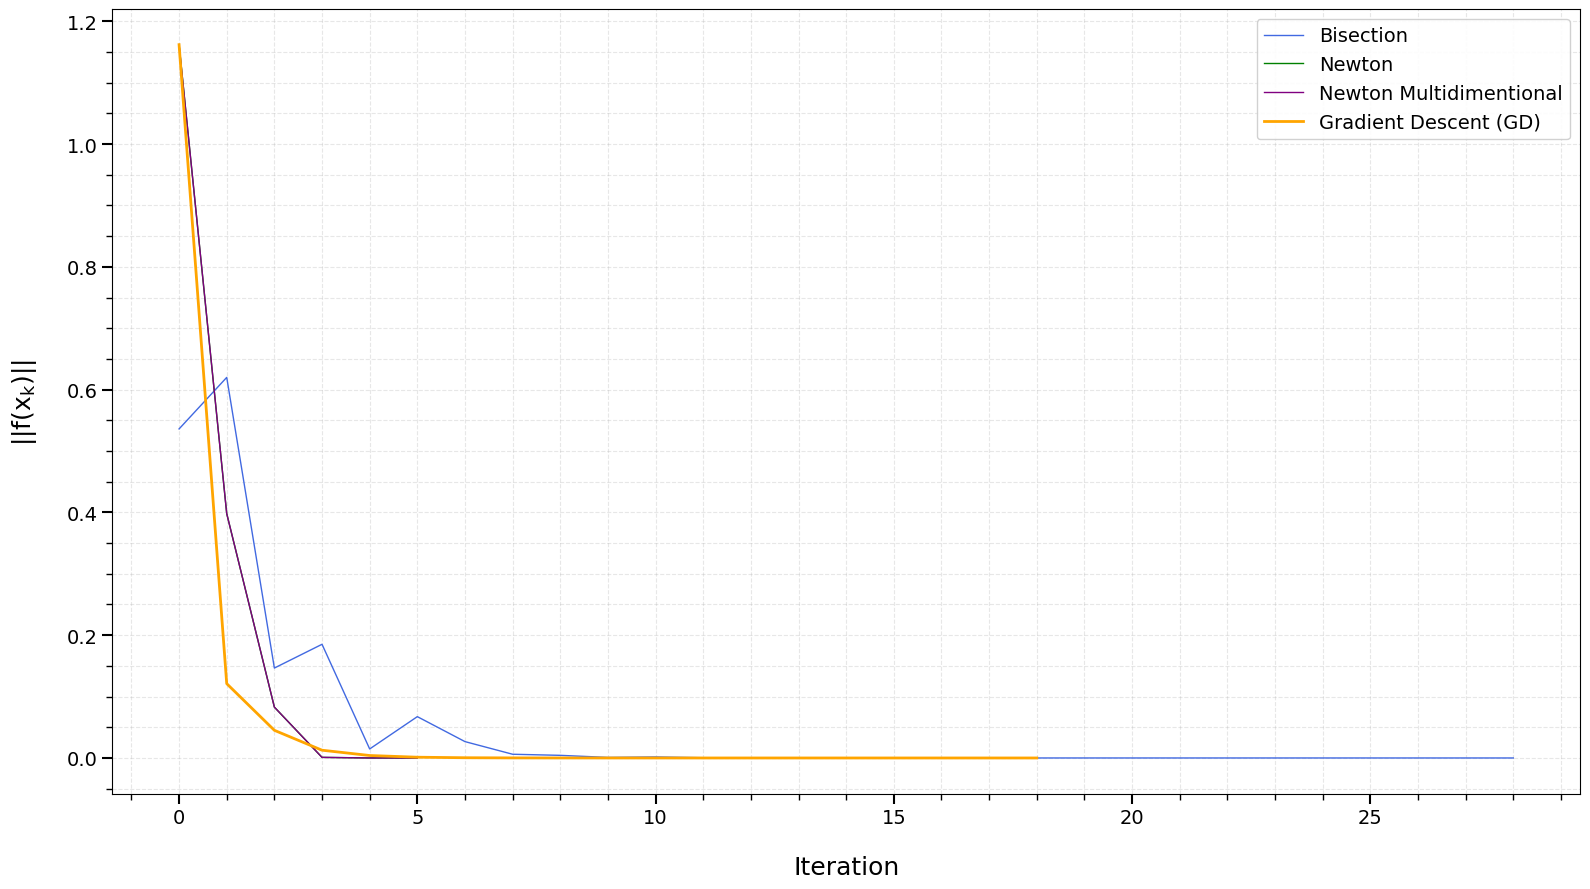

In [ ]:
# ----------------------------------------------------------------------
# Тестирование на уравнении 2x² + 5x - 3 = 0
# ----------------------------------------------------------------------
# Уравнение: 2x^2 + 5x – 3 = 0. Корни: x1 = 0.5, x2 = -3.
# Мы ищем 2-й корень x1 = 0.5 (из интервала [0, 2])
# f(x): R^1 -> R^1, поэтому для solve_gd используем np.array([x]) -> np.array([f(x)])

# def f_scalar(x):
#     return 2 * x ** 2 + 5 * x - 3

# def f_torch(x: torch.Tensor) -> torch.Tensor:
#     return 2 * x**2 + 5 * x - 3

# def f_scalar_prime(x):
#     return derr.derivative(f_scalar, x)

# def f(x: np.ndarray) -> np.ndarray:
#     # Оборачиваем скалярную функцию для solve_newton_multidim и solve_gd
#     return np.array([f_scalar(x[0])])

# def jac_f(x: np.ndarray) -> np.ndarray:
#     # Производная f'(x) = 4x + 5. Возвращаем 1x1 массив.
#     return np.array([[derr.derivative(f_scalar, x[0])]])

# def g(x):
#     return (3 - 2 * x**2) / 5

# Уравнение: 1.3e^(-0.1x^2)sin(2.5πx) + 0.25x = 0. 
# Мы ищем корень x=1.23572 (из интервала [0.845, 1.5]).
# f(x): R^1 -> R^1, поэтому для solve_gd используем np.array([x]) -> np.array([f(x)])

def f_scalar(x):
    # 1.3 * exp(-0.1*x^2) * sin(2.5*pi*x) + 0.25*x
    return 1.3 * np.exp(-0.1 * x**2) * np.sin(2.5 * np.pi * x) + 0.25 * x

def f_torch(x: torch.Tensor) -> torch.Tensor:
    return 1.3 * torch.exp(-0.1 * x.pow(2)) * torch.sin(2.5 * torch.pi * x) + 0.25 * x

def f_scalar_prime(x):
    return derr.derivative(f_scalar, x)

def f(x: np.ndarray) -> np.ndarray:
    return np.array([f_scalar(x[0])])

def jac_f(x: np.ndarray) -> np.ndarray:
    # Производная f'(x). Возвращаем 1x1 массив.
    return np.array([[derr.derivative(f_scalar, x[0])]])

def g(x):
    return -1.3*np.exp(-0.1 * x**2) * np.sin(2.5 * np.pi * x) / 0.25

# Здесь x0 берется для корня x=0.5. Используем np.array([0]) для многомерных методов.
result_bisection = solve_bisection(f_scalar, a=0.845, b=1.5, xtol=1e-9, rtol=1e-9, maxiter=100, full_output=True)
result_simple_iteration = solve_simple_iteration(g, x0=1.088, atol=1e-9, maxiter=100, full_output=True)
result_newton = solve_newton(f_scalar, 1.088, f_scalar_prime, atol=1e-9, full_output=True)
result_newton_multidim = solve_newton_multidim(f, np.array([1.088]), jac=jac_f, atol=1e-9, maxiter=100, full_output=True)
result_gd = solve_gd(f, np.array([1.088]), jac=jac_f, lr=0.01, atol=1e-9, maxiter=100, full_output=True)
result_gd_torch_adam = solve_gd_torch_adam(
    f_torch,
    np.array([1.088]),
    lr=0.05,
    atol=1e-9,
    maxiter=100,
    full_output=True,
)

# --- Вывод результатов ---
print(f"bisection: {result_bisection.root} (итераций: {result_bisection.iterations})")
print(f"simple_iteration: {result_simple_iteration.root} (итераций: {result_simple_iteration.iterations})")
print(f"newton: {result_newton.root} (итераций: {result_newton.iterations})")
print(f"newton_multidim: {result_newton_multidim.root} (итераций: {result_newton_multidim.iterations})")
print(f"gradient_descent: {result_gd.root} (итераций: {result_gd.iterations})")
print(f"torch_adam: {result_gd_torch_adam.root} (итераций: {result_gd_torch_adam.iterations})")

# --- Построение графиков ---
plotter = Plotter(
    title=None,
    xlabel='Iteration',
    ylabel=r"$\mathrm{||f(x_{k})||}$"
)

plot_args_dict = \
{
    "bisection":          PlotParams(linestyle="-", color="royalblue", linewidth=1, label='Bisection'),
    "simple_iteration":   PlotParams(linestyle="-", color="red", linewidth=1, label='Simple Iteration'),
    "newton":             PlotParams(linestyle="-", color="green", linewidth=1, label='Newton'),
    "newton_multidim":    PlotParams(linestyle="-", color="purple", linewidth=1, label='Newton Multidimentional'),
    "gradient_descent":   PlotParams(linestyle="-", color="orange", linewidth=2, label='Gradient Descent (GD)'),
    "torch_adam":         PlotParams(linestyle="-", color="black", linewidth=2, label='Adam (PyTorch)'),
}

plotter.add_plot(np.arange(result_bisection.iterations), result_bisection.f_norm_history, plot_args_dict['bisection'])
# plotter.add_plot(np.arange(result_simple_iteration.iterations), result_simple_iteration.f_norm_history, plot_args_dict['simple_iteration'])
plotter.add_plot(np.arange(result_newton.iterations), result_newton.f_norm_history, plot_args_dict['newton'])
plotter.add_plot(np.arange(result_newton_multidim.iterations), result_newton_multidim.f_norm_history, plot_args_dict['newton_multidim'])
plotter.add_plot(np.arange(result_gd.iterations), result_gd.f_norm_history, plot_args_dict['gradient_descent'])
# plotter.add_plot(np.arange(result_gd_torch_adam.iterations), result_gd_torch_adam.f_norm_history, plot_args_dict['torch_adam'])

plotter.finalize_and_show()

newton_multidim: [1.0484   0.412622] (итераций: 5)
gradient_descent: [1.0484  0.41262] (итераций: 17)
torch_adam: [1.048391 0.412614] (итераций: 170)


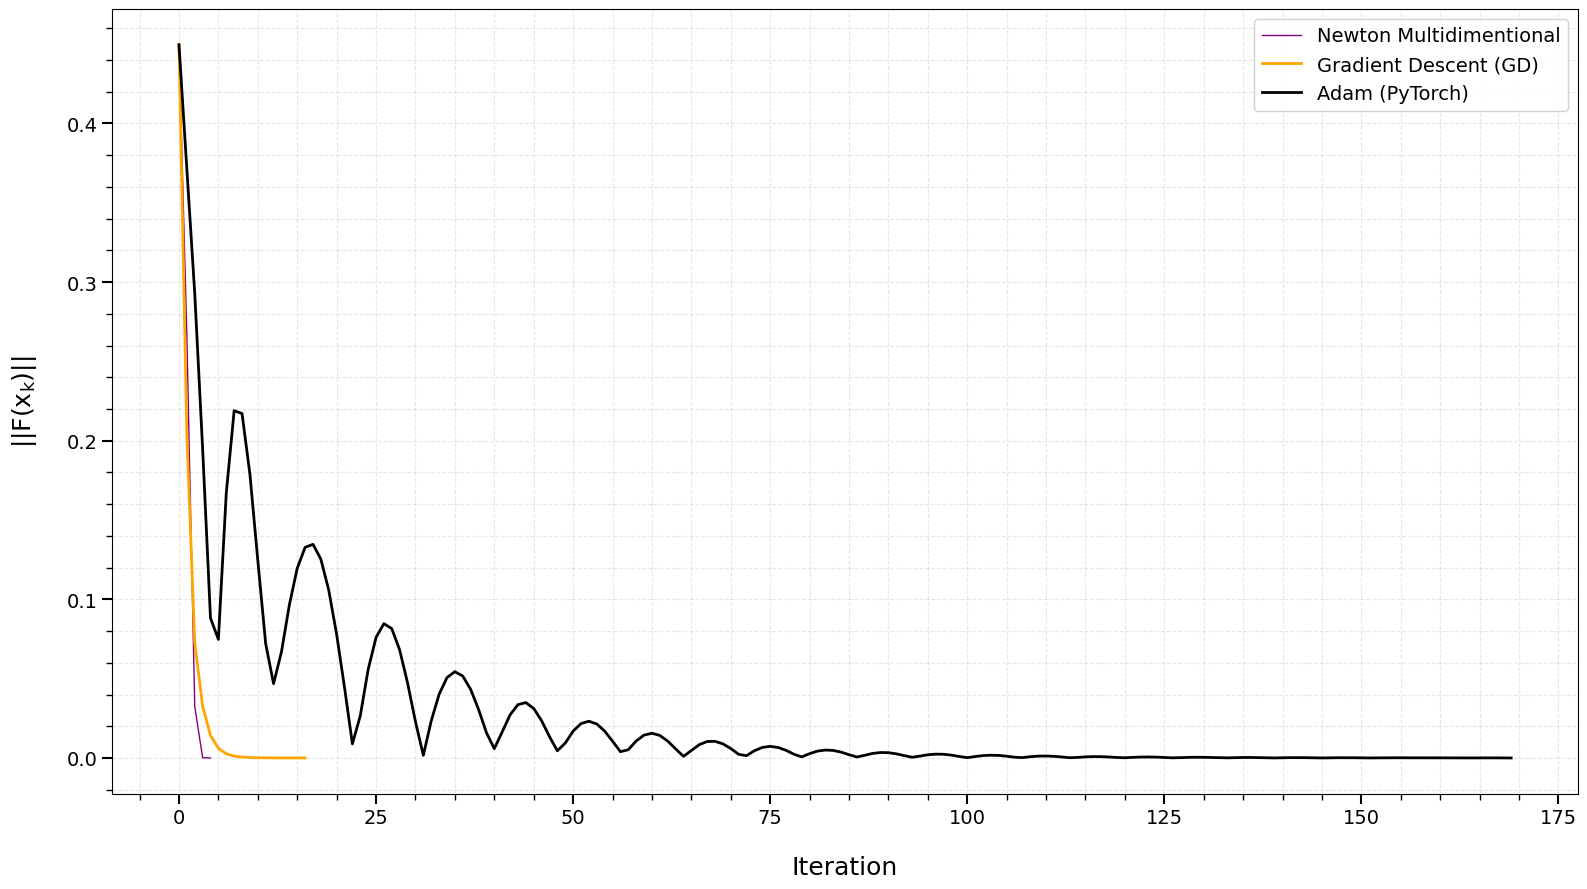

In [279]:
# -------------------------------------------------------------------------------------------------
# IV.12.4 б): Вычисление координат точек пересечения кривых с точностью Epsilon=10^-3.
#
# Система уравнений F(x) = 0:
# F1(x, y) = tg(xy + 0.4) - x^2 = 0
# F2(x, y) = 0.6x^2 + 2y^2 - 1 = 0
# -------------------------------------------------------------------------------------------------

# --- Целевая система F(x) = 0 для x_vec = [x, y] ---

def F_numpy(x_vec: np.ndarray) -> np.ndarray:
    x, y = x_vec[0], x_vec[1]
    F1 = np.tan(x * y + 0.4) - x**2
    F2 = 0.6 * x**2 + 2 * y**2 - 1
    return np.array([F1, F2])

def F_torch(x_tensor: torch.Tensor) -> torch.Tensor:
    x, y = x_tensor[0], x_tensor[1]
    F1 = torch.tan(x * y + 0.4) - x.pow(2)
    F2 = 0.6 * x.pow(2) + 2 * y.pow(2) - 1
    return torch.stack([F1, F2])

# --- Численный Якобиан J = dF/dx ---

jac = lambda x: derr.jacobian(F_numpy, x)

# --- Начальное приближение и параметры ---
x0_initial = np.array([1.0, 0.2]) 
atol_target = 1e-5 # atol=1e-5 для обеспечения точности 10^-3
max_iterations = 1000

# --- Решение системы с использованием различных методов ---

result_newton_multidim = solve_newton_multidim(
    F_numpy, x0_initial, jac=jac, atol=atol_target, maxiter=max_iterations, full_output=True
)

result_gd = solve_gd(
    F_numpy, x0_initial, jac=jac, lr=0.1, atol=atol_target, maxiter=max_iterations, full_output=True
)

result_gd_torch_adam = solve_gd_torch_adam(
    F_torch, x0_initial, lr=0.05, atol=atol_target, maxiter=max_iterations, full_output=True
)

# --- Вывод результатов ---
print(f"newton_multidim: {result_newton_multidim.root.round(6)} (итераций: {result_newton_multidim.iterations})")
print(f"gradient_descent: {result_gd.root.round(6)} (итераций: {result_gd.iterations})")
print(f"torch_adam: {result_gd_torch_adam.root.round(6)} (итераций: {result_gd_torch_adam.iterations})")

# --- Построение графиков (Демонстрация сходимости) ---

plotter = Plotter(
    title=None,
    xlabel='Iteration',
    ylabel=r"$\mathrm{||F(x_{k})||}$"
)

plot_args_dict = {
    "newton_multidim": PlotParams(linestyle="-", color="purple", linewidth=1, label='Newton Multidimentional'),
    "gradient_descent": PlotParams(linestyle="-", color="orange", linewidth=2, label='Gradient Descent (GD)'),
    "torch_adam": PlotParams(linestyle="-", color="black", linewidth=2, label='Adam (PyTorch)'),
}

plotter.add_plot(np.arange(result_newton_multidim.iterations), result_newton_multidim.f_norm_history, plot_args_dict['newton_multidim'])
plotter.add_plot(np.arange(result_gd.iterations), result_gd.f_norm_history, plot_args_dict['gradient_descent'])
plotter.add_plot(np.arange(result_gd_torch_adam.iterations), result_gd_torch_adam.f_norm_history, plot_args_dict['torch_adam'])

plotter.finalize_and_show()

newton_multidim: [ 1.791339 -0.344221] (итераций: 6)
gradient_descent: [ 1.791338 -0.344221] (итераций: 33)
torch_adam: [ 1.791338 -0.344221] (итераций: 249)


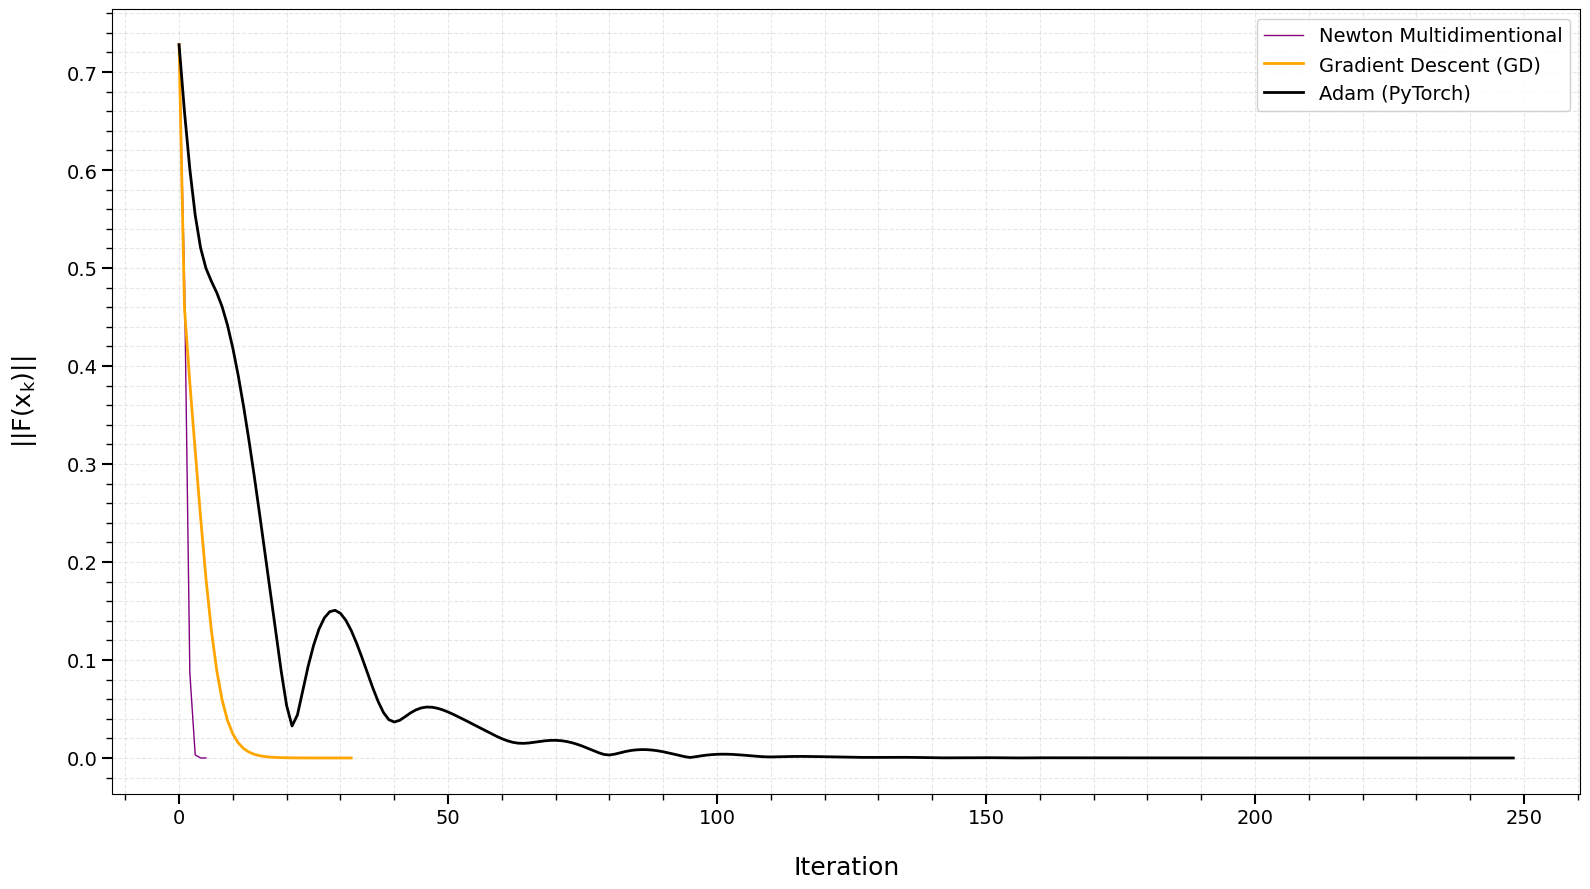

In [283]:
# -------------------------------------------------------------------------------------------------
# IV.12.6 г): Отыскать все точки пересечения с точностью Epsilon=10^-5.
#
# Система уравнений F(x) = 0:
# F1(x, y) = sin(x) - y - 1.32 = 0
# F2(x, y) = cos(y) - x + 0.85 = 0
# -------------------------------------------------------------------------------------------------

# --- Целевая система F(x) = 0 для x_vec = [x, y] ---

def F_numpy(x_vec: np.ndarray) -> np.ndarray:
    x, y = x_vec[0], x_vec[1]
    F1 = np.sin(x) - y - 1.32
    F2 = np.cos(y) - x + 0.85
    return np.array([F1, F2])

def F_torch(x_tensor: torch.Tensor) -> torch.Tensor:
    x, y = x_tensor[0], x_tensor[1]
    F1 = torch.sin(x) - y - 1.32
    F2 = torch.cos(y) - x + 0.85
    return torch.stack([F1, F2])

# --- Численный Якобиан J = dF/dx ---

jac = lambda x: derr.jacobian(F_numpy, x)

# --- Начальное приближение и параметры ---
x0_initial = np.array([1, -0.5]) 
atol_target = 1e-6 # atol=1e-6 для обеспечения точности 10^-3
max_iterations = 1000

# --- Решение системы с использованием различных методов ---

result_newton_multidim = solve_newton_multidim(
    F_numpy, x0_initial, jac=jac, atol=atol_target, maxiter=max_iterations, full_output=True
)

result_gd = solve_gd(
    F_numpy, x0_initial, jac=jac, lr=0.2, atol=atol_target, maxiter=max_iterations, full_output=True
)

result_gd_torch_adam = solve_gd_torch_adam(
    F_torch, x0_initial, lr=0.05, atol=atol_target, maxiter=max_iterations, full_output=True
)

# --- Вывод результатов ---
print(f"newton_multidim: {result_newton_multidim.root.round(6)} (итераций: {result_newton_multidim.iterations})")
print(f"gradient_descent: {result_gd.root.round(6)} (итераций: {result_gd.iterations})")
print(f"torch_adam: {result_gd_torch_adam.root.round(6)} (итераций: {result_gd_torch_adam.iterations})")

# --- Построение графиков (Демонстрация сходимости) ---

plotter = Plotter(
    title=None,
    xlabel='Iteration',
    ylabel=r"$\mathrm{||F(x_{k})||}$"
)

plot_args_dict = {
    "newton_multidim": PlotParams(linestyle="-", color="purple", linewidth=1, label='Newton Multidimentional'),
    "gradient_descent": PlotParams(linestyle="-", color="orange", linewidth=2, label='Gradient Descent (GD)'),
    "torch_adam": PlotParams(linestyle="-", color="black", linewidth=2, label='Adam (PyTorch)'),
}

plotter.add_plot(np.arange(result_newton_multidim.iterations), result_newton_multidim.f_norm_history, plot_args_dict['newton_multidim'])
plotter.add_plot(np.arange(result_gd.iterations), result_gd.f_norm_history, plot_args_dict['gradient_descent'])
plotter.add_plot(np.arange(result_gd_torch_adam.iterations), result_gd_torch_adam.f_norm_history, plot_args_dict['torch_adam'])

plotter.finalize_and_show()